In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display


In [64]:
# Vamos conduzir uma análise superficial do nosso dataframe:
df = pd.read_csv('train.csv')

print(df.shape)
df.head(3)


(594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


### Temos uma base de dados com 21 colunas. São bastante colunas pra se trabalhar, e a depender do tipo do modelo, poderia ser necessário rodar um PCA, especialmente se tivermos muitas variáveis categóricas com muitas categorias em seu perfil. Para analisar isso, vamos dar uma olhada nas informações de tipo dos nossos dados.

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

### Temos muitas variáveis object. Vamos ver o quão numerosos são os valores únicos. Antes, separaremos nossas variáveis em categóricas e numéricas fazendo:

In [66]:
num_vars = df.select_dtypes(include='number').columns.tolist()
cat_vars = df.select_dtypes(exclude='number').columns.tolist()

display(f'As variáveis numéricas são {num_vars}, _____ As variávies categóricas são{cat_vars}')

"As variáveis numéricas são ['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], _____ As variávies categóricas são['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']"

#### Vamos agora analisar a quantidade de tipos em cata variável categórica. Para isso, fazemos:

In [67]:
df[cat_vars].nunique()    

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2
dtype: int64

#### Não temos muitas categorias "granuladas" em nossos dados. No entanto, ainda assim, ee formos olhar, essas várias variáveis categóricas fazem nosso df ter muito mais do que as "colunas" que aparenta ter, principalmente se formos usar um método que não tem tratamento categórico nativo, por exemplo, o Logistic Regressor.

#### Rodando o código abaixo, percebemos que nos nossos dados não existem dados faltando. Portanto, não é necessário fazermos um tratamento de missings.

In [68]:
df.isna().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

#### Vamos agora analisar a distribuição de nossas variáveis, e ver se será necessário fazer algum tratamento de outliers. Para isso, usaremos o boxplot:

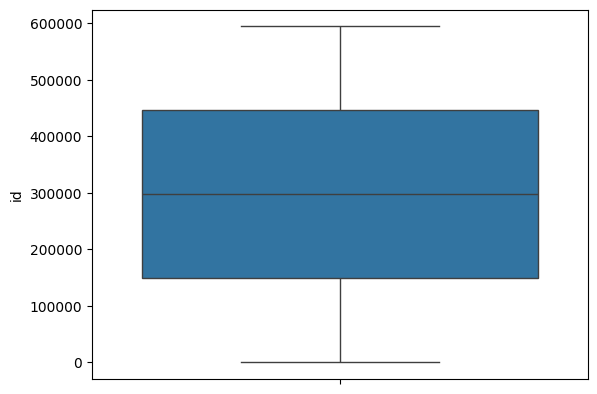

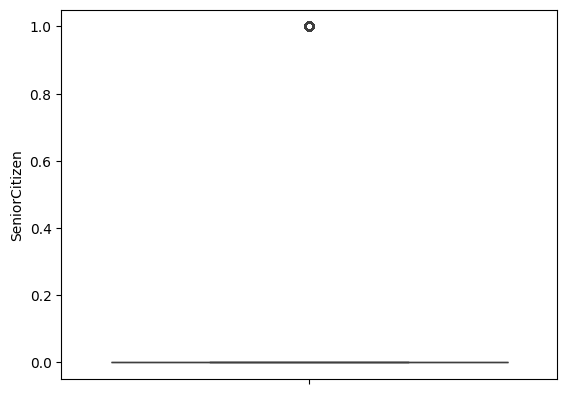

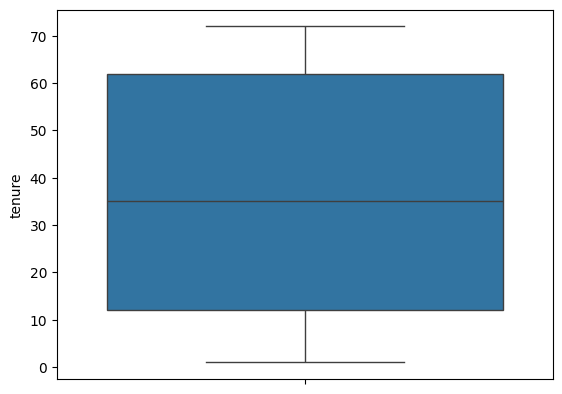

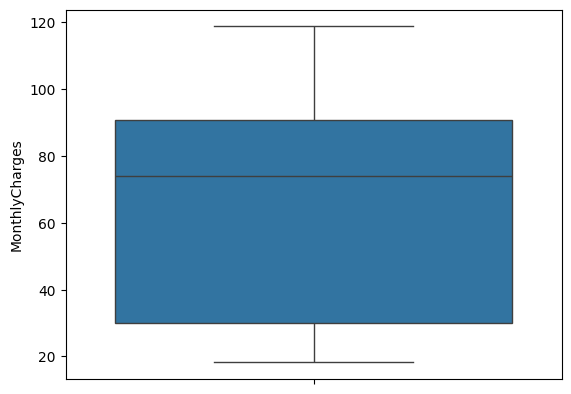

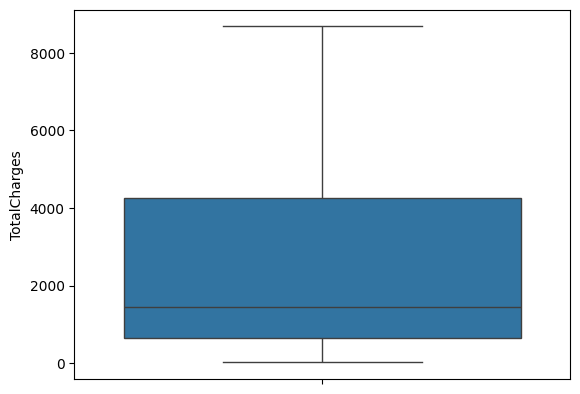

In [69]:
for var in num_vars:
    sns.boxplot(data=df, y=var)
    plt.show()
    

In [70]:
df['SeniorCitizen'].value_counts()

SeniorCitizen
0    526395
1     67799
Name: count, dtype: int64

#### Podemos ver que o único outlier indicado está em SeniorCitizen. No entanto, não se trata de um outlier verdadeiro, e sim de uma variável categórica sendo tratada como numérica. Resolveremos isso quando formos transformar nossas variáveis object em categóricas quando formos criar o nosso df_att.pkl, que será utilizado ao longo do projeto, com as variáveis devidamente categorizadas.

#### Aproveitando, vamos verificar a relação desta variável com o nosso target.

<Axes: xlabel='Churn', ylabel='SeniorCitizen'>

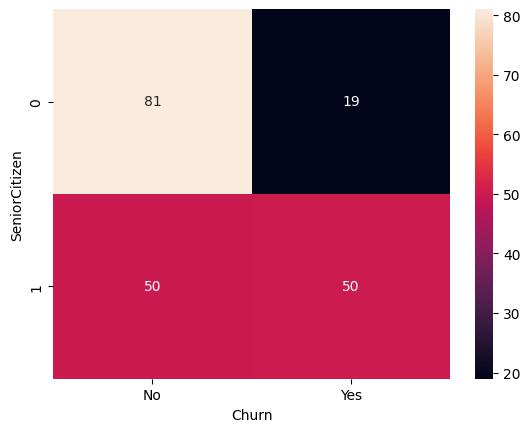

In [71]:
matrix = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

sns.heatmap(matrix, annot=True)

#### Notamos que existe forte relação positiva entre o Senior Citizen 1 e o Churn NO, sendo que ele possui um churn relativamente maior.


#### Vamos a seguir verificar o balanço da nossa variável resposta.

In [72]:
df['Churn'].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

#### Nossa base de dados possui forte desbalanceamento na variável resposta, o que nos induz (e basicamente obriga) a usar StratifiedKFold no treino dos nossos dados.

In [73]:
num_vars

['id', 'SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [74]:
for var in num_vars:
    display(df[var].value_counts())

id
0         1
1         1
2         1
3         1
4         1
         ..
594189    1
594190    1
594191    1
594192    1
594193    1
Name: count, Length: 594194, dtype: int64

SeniorCitizen
0    526395
1     67799
Name: count, dtype: int64

tenure
72    56411
1     29182
71    20763
2     16766
3     13478
      ...  
40     4203
21     3862
44     3496
39     3396
36     2562
Name: count, Length: 72, dtype: int64

MonthlyCharges
20.05    7436
19.95    5718
19.70    5705
20.00    5493
19.85    5114
         ... 
32.45       1
31.30       1
89.24       1
21.70       1
46.15       1
Name: count, Length: 1921, dtype: int64

TotalCharges
6096.90    850
1110.05    846
6448.05    734
854.90     721
7133.25    619
          ... 
5928.95      1
5813.20      1
2813.55      1
3238.80      1
157.25       1
Name: count, Length: 31910, dtype: int64

#### Aparentemente, a única variável a precisar desse tratamento será SeniorCitizen. Realizaremos o processo a seguir.

In [75]:
cat_vars.append('SeniorCitizen')

cat_vars

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [76]:
df[cat_vars] = df[cat_vars].astype('category')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No':0}).astype(int)

In [77]:
df['Churn'].value_counts()

Churn
0    460377
1    133817
Name: count, dtype: int64

In [78]:
df_att = df.copy()

df_att.to_pickle('df_att.pkl')

df_att = None

df_att = pd.read_pickle('df_att.pkl')


In [79]:
df_att.head(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,0
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,0
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,0


In [80]:
df_att.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype   
---  ------            --------------   -----   
 0   id                594194 non-null  int64   
 1   gender            594194 non-null  category
 2   SeniorCitizen     594194 non-null  category
 3   Partner           594194 non-null  category
 4   Dependents        594194 non-null  category
 5   tenure            594194 non-null  int64   
 6   PhoneService      594194 non-null  category
 7   MultipleLines     594194 non-null  category
 8   InternetService   594194 non-null  category
 9   OnlineSecurity    594194 non-null  category
 10  OnlineBackup      594194 non-null  category
 11  DeviceProtection  594194 non-null  category
 12  TechSupport       594194 non-null  category
 13  StreamingTV       594194 non-null  category
 14  StreamingMovies   594194 non-null  category
 15  Contract          594194 non-null  category
 16  Pa

In [92]:
def transforming_function(df):
    num_vars = df.select_dtypes(include='number').columns.tolist()
    cat_vars = df.select_dtypes(exclude='number').columns.tolist()

    if 'Churn' in df.columns:
        df['Churn'] = df['Churn'].map({'Yes': 1, 'No':0}).astype(int)
        cat_vars.remove('Churn')
    df[cat_vars] = df[cat_vars].astype('category')
        
    return df

In [93]:
df_test = pd.read_csv('test.csv')

df_test.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [94]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254655 entries, 0 to 254654
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                254655 non-null  int64  
 1   gender            254655 non-null  object 
 2   SeniorCitizen     254655 non-null  int64  
 3   Partner           254655 non-null  object 
 4   Dependents        254655 non-null  object 
 5   tenure            254655 non-null  int64  
 6   PhoneService      254655 non-null  object 
 7   MultipleLines     254655 non-null  object 
 8   InternetService   254655 non-null  object 
 9   OnlineSecurity    254655 non-null  object 
 10  OnlineBackup      254655 non-null  object 
 11  DeviceProtection  254655 non-null  object 
 12  TechSupport       254655 non-null  object 
 13  StreamingTV       254655 non-null  object 
 14  StreamingMovies   254655 non-null  object 
 15  Contract          254655 non-null  object 
 16  PaperlessBilling  25

In [102]:
df_test_att = transforming_function(df_test)

df_test_att.head(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


In [103]:
df_test_att.to_pickle('test_att.pkl')

